Use the Titanic dataset to build a model that predicts whether a passenger on surved or not

## Data Dictionary
- survival: 0 = No, 1 = Yes
- pclass: Ticket class 1 = 1st, 2 = 2nd, 3 = 3rd
- sex: Male, Female
- Age: Age in years
- sibsp: Number of siblings and spouses aboard
- parch: Number of parents and children aboard
- ticket: Ticket number
- fare: Passenger fare
- cabin: Cabin number
- embarked: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:

test_data = pd.read_csv("Titanic_Dataset.csv.csv") # load the file

In [3]:
test_data.shape

(891, 13)

In [4]:
test_data.head()

,PassengerId,Survived,Pclass,Name,Name2,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,Braund,Mr. Owen Harris,Male,22.0,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,Cumings,Mrs. John Bradley (Florence Briggs Thayer),Female,38.0,1,0,PC 17599,71.28,C85,C
2,3,1,3,Heikkinen,Miss. Laina,Female,26.0,0,0,STON/O2. 3101282,7.93,NaN,S
3,4,1,1,Futrelle,Mrs. Jacques Heath (Lily May Peel),Female,35.0,1,0,113803,53.10,C123,S
4,5,0,3,Allen,Mr. William Henry,Male,35.0,0,0,373450,8.05,NaN,S


In [5]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Name2        891 non-null    str    
 5   Sex          891 non-null    str    
 6   Age          714 non-null    float64
 7   SibSp        891 non-null    int64  
 8   Parch        891 non-null    int64  
 9   Ticket       891 non-null    str    
 10  Fare         891 non-null    float64
 11  Cabin        204 non-null    str    
 12  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(6)
memory usage: 90.6 KB


In [6]:
test_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.205017
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693389
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.915000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.450000
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.330000


In [7]:
test_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Name2            0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# droping unnecessary columns which we dont need

In [8]:
# droping cabin bcz it is having too much missing value
test_data = test_data.drop("Cabin", axis=1)

In [9]:
test_data = test_data.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

In [10]:
print(test_data.columns)

Index(['Survived', 'Pclass', 'Name2', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='str')


In [11]:
#filling missing "Age" values with median
test_data['Age'].fillna(test_data['Age'].median())

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [12]:
# filling missing 'embarked' values with mode
test_data['Embarked'].fillna(test_data['Embarked'].mode()[0])

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

In [13]:
test_data.isnull().sum()

Survived      0
Pclass        0
Name2         0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [14]:
test_data .info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name2     891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Fare      891 non-null    float64
 8   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(3)
memory usage: 62.8 KB


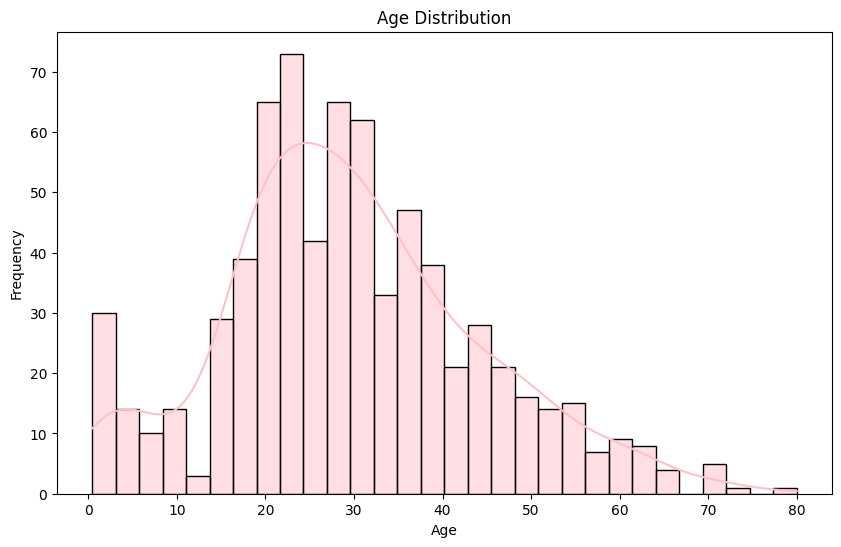

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(test_data['Age'].dropna(), kde=True, bins=30, color='pink')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [16]:
# change the sex object data type into int so that we can do  ml operations function
mapping={'male':1,'female':0}
test_data['Sex']=test_data['Sex'].map(mapping)

In [17]:
# change embarked object data type into int so that we can do  ml operations function
mapping={'S':0,'C':1,'Q':2}
test_data['Embarked']=test_data['Embarked'].map(mapping)

In [18]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name2     891 non-null    str    
 3   Sex       0 non-null      float64
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Fare      891 non-null    float64
 8   Embarked  889 non-null    float64
dtypes: float64(4), int64(4), str(1)
memory usage: 62.8 KB


In [19]:
test_data.head()

,Survived,Pclass,Name2,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,Mr. Owen Harris,NaN,22.0,1,0,7.25,0.0
1,1,1,Mrs. John Bradley (Florence Briggs Thayer),NaN,38.0,1,0,71.28,1.0
2,1,3,Miss. Laina,NaN,26.0,0,0,7.93,0.0
3,1,1,Mrs. Jacques Heath (Lily May Peel),NaN,35.0,1,0,53.10,0.0
4,0,3,Mr. William Henry,NaN,35.0,0,0,8.05,0.0


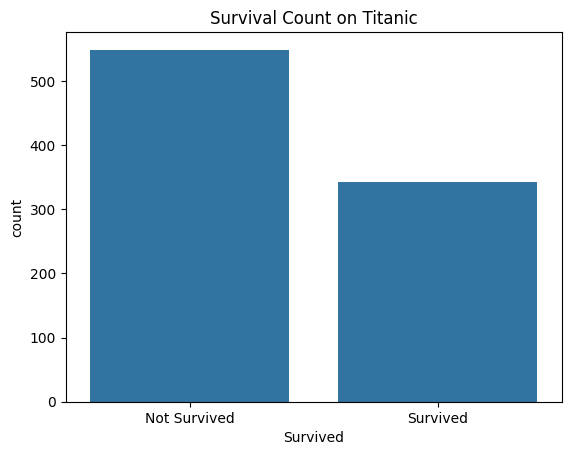

In [20]:
sns.countplot(x='Survived', data=test_data)
plt.title('Survival Count on Titanic')
plt.xticks([0,1],['Not Survived','Survived'])
plt.show()

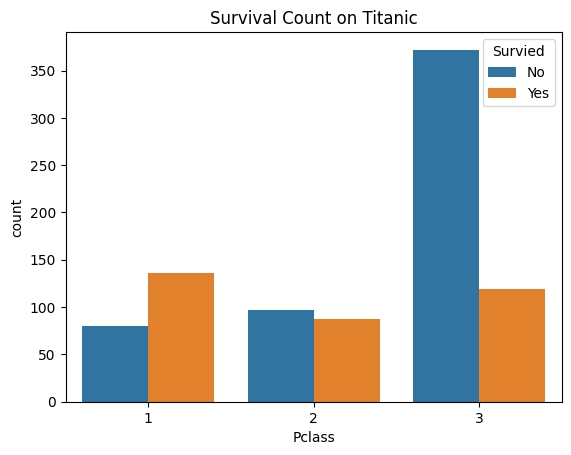

In [21]:
sns.countplot(x='Pclass', hue='Survived', data=test_data)
plt.title('Survival Count on Titanic')
plt.legend(title='Survied',labels=['No','Yes'])
plt.show()

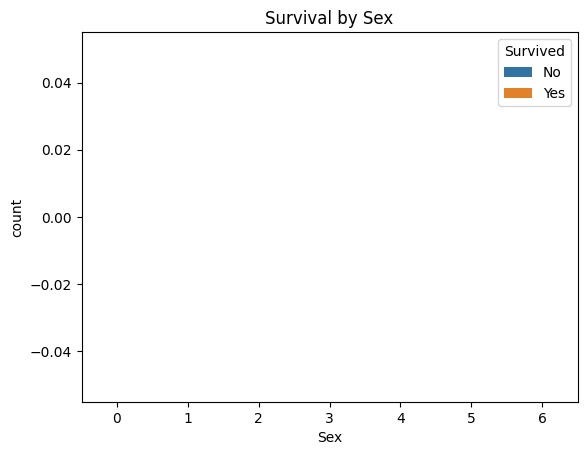

In [22]:
sns.countplot(x='Sex', hue='Survived', data=test_data)
plt.title('Survival by Sex')
plt.legend(title='Survived',labels=['No','Yes'])
plt.show()

In [23]:
test_data.head()

,Survived,Pclass,Name2,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,Mr. Owen Harris,NaN,22.0,1,0,7.25,0.0
1,1,1,Mrs. John Bradley (Florence Briggs Thayer),NaN,38.0,1,0,71.28,1.0
2,1,3,Miss. Laina,NaN,26.0,0,0,7.93,0.0
3,1,1,Mrs. Jacques Heath (Lily May Peel),NaN,35.0,1,0,53.10,0.0
4,0,3,Mr. William Henry,NaN,35.0,0,0,8.05,0.0


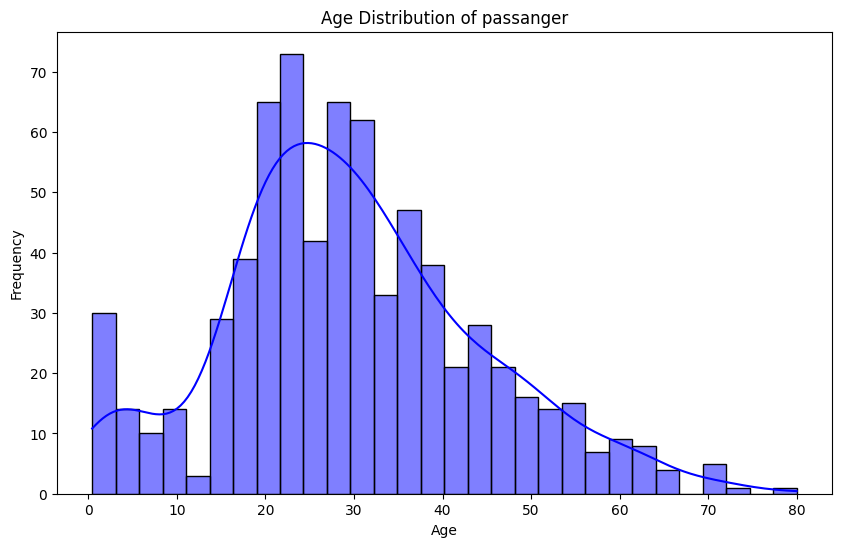

In [24]:

plt.figure(figsize=(10, 6))
sns.histplot(test_data['Age'].dropna(), kde=True, bins=30, color='blue')
plt.title('Age Distribution of passanger')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

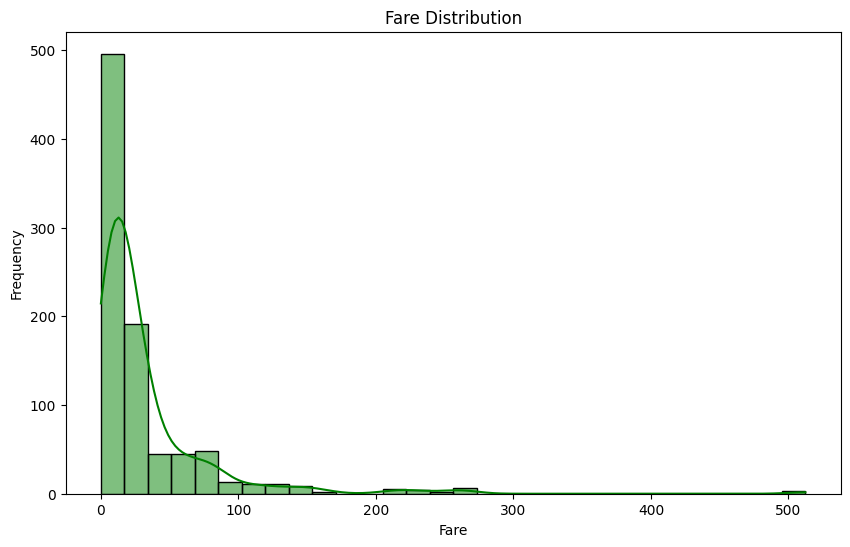

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(test_data['Fare'], kde=True, bins=30, color='green')
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

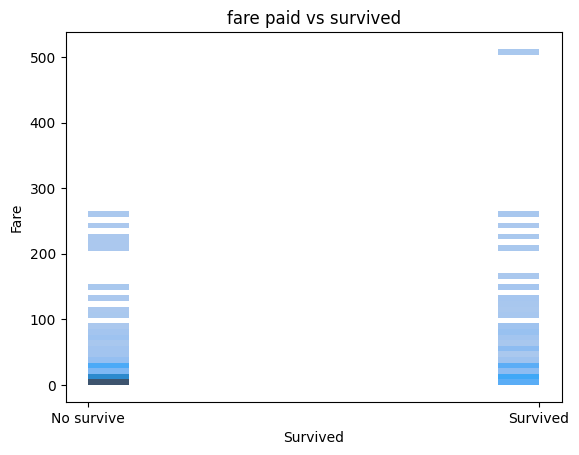

In [26]:
sns.histplot(x='Survived',y='Fare',data=test_data)
plt.title('fare paid vs survived')
plt.xticks([0,1],['No survive','Survived'])
plt.show()

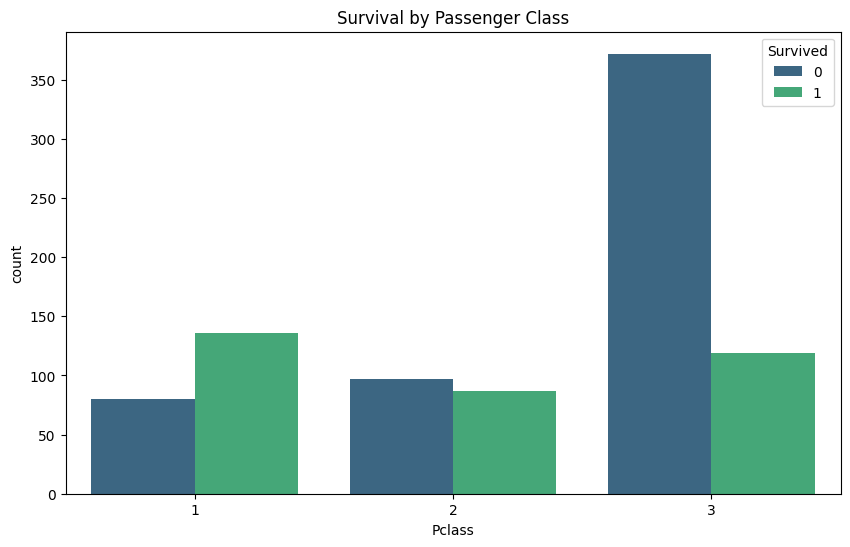

In [27]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Pclass', hue='Survived', data=test_data, palette='viridis')
plt.title('Survival by Passenger Class')
plt.show()

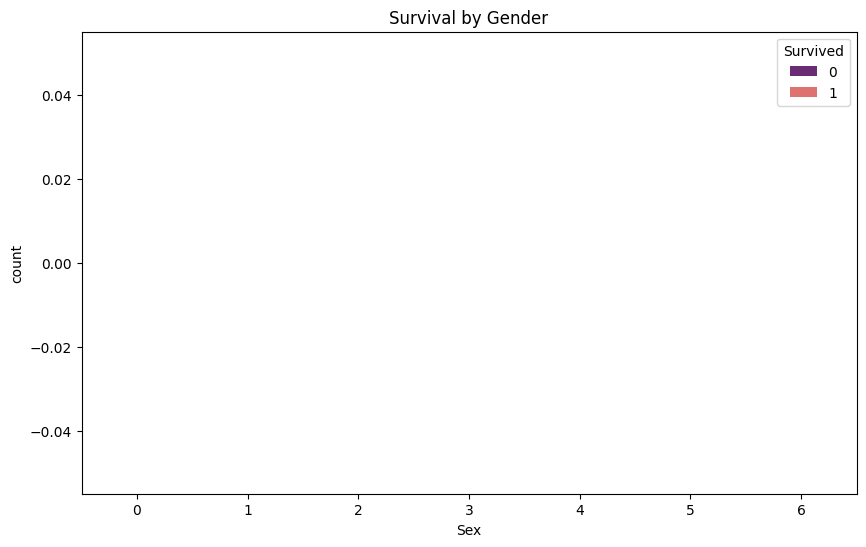

In [28]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Sex', hue='Survived', data=test_data, palette='magma')
plt.title('Survival by Gender')
plt.show()

In [29]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name2     891 non-null    str    
 3   Sex       0 non-null      float64
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Fare      891 non-null    float64
 8   Embarked  889 non-null    float64
dtypes: float64(4), int64(4), str(1)
memory usage: 62.8 KB


Building the machine learning modle

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
# split the data into training and testing sets
X=test_data.drop('Survived',axis=1)
y=test_data['Survived']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

imports the logistic Regression model from sklearn.learn_model library

In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
from sklearn.model_selection import train_test_split



In [33]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

ValueError: could not convert string to float: ' Mr. Austen'

In [ ]:
print(y_pred)

In [ ]:
# evaluate the model's accuracy
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy:.2f}")

In [ ]:
plt.figure(figsize=(12, 8))
# Select only numeric columns for correlation
numeric_cols = test_data.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()